<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


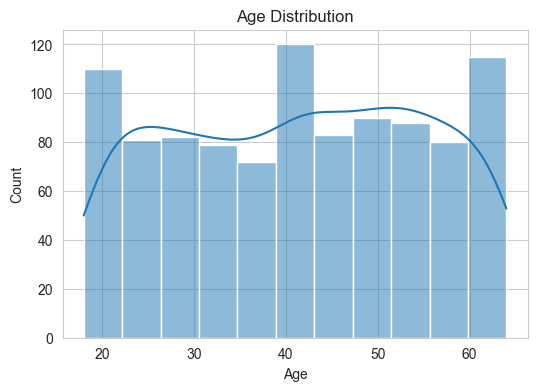

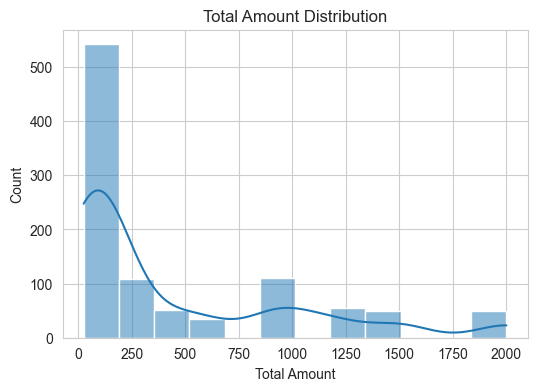

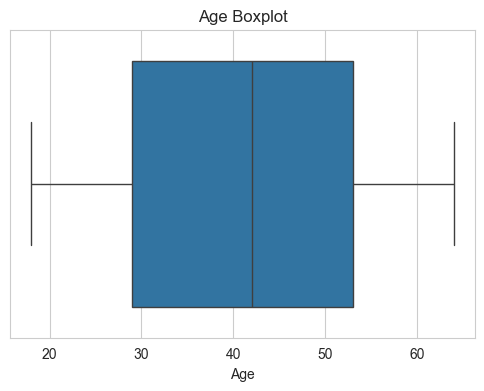

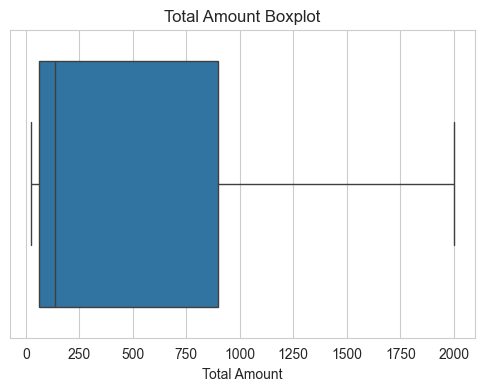

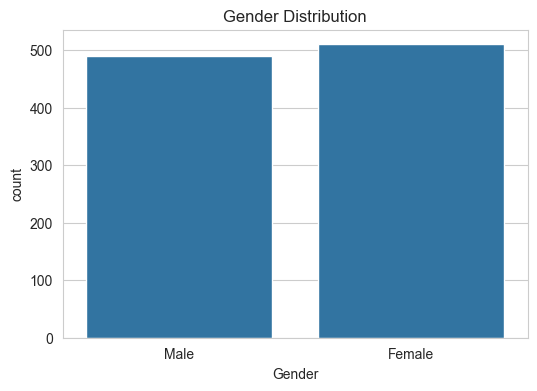

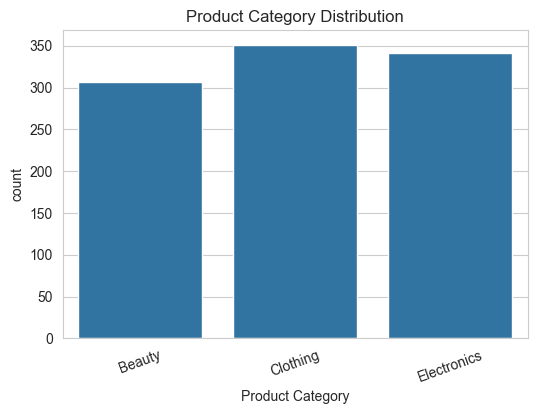

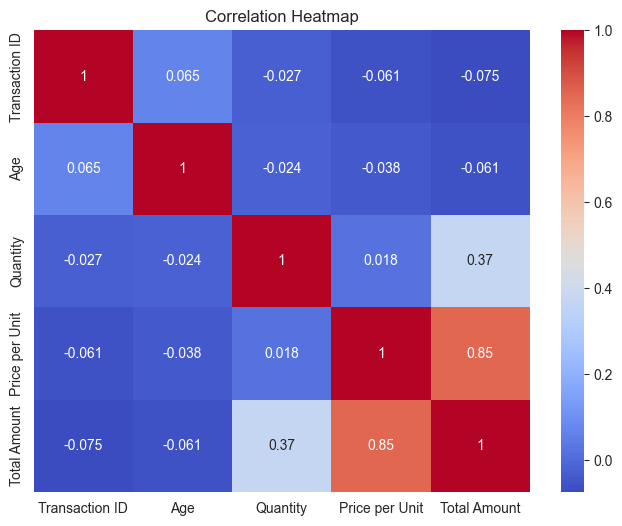

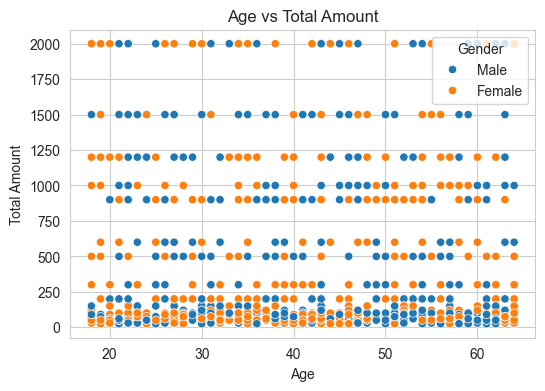

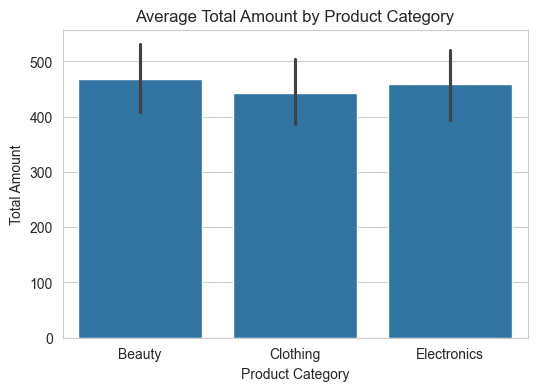

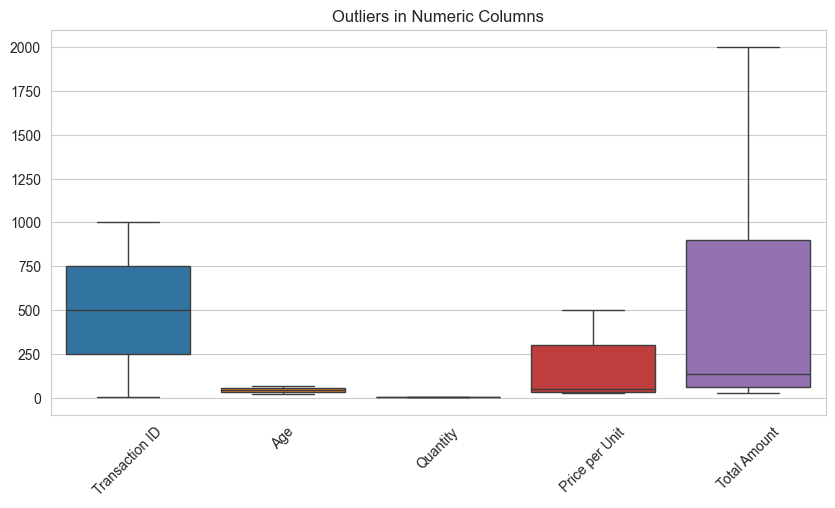

       Transaction ID         Age     Quantity  Price per Unit  Total Amount
count     1000.000000  1000.00000  1000.000000     1000.000000   1000.000000
mean       500.500000    41.39200     2.514000      179.890000    456.000000
std        288.819436    13.68143     1.132734      189.681356    559.997632
min          1.000000    18.00000     1.000000       25.000000     25.000000
25%        250.750000    29.00000     1.000000       30.000000     60.000000
50%        500.500000    42.00000     3.000000       50.000000    135.000000
75%        750.250000    53.00000     4.000000      300.000000    900.000000
max       1000.000000    64.00000     4.000000      500.000000   2000.000000

Average Total Amount by Gender
Gender
Female    456.549020
Male      455.428571
Name: Total Amount, dtype: float64

Total Sales by Product Category
Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64

Average Quantity by Product Category
Prod

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("E:/Downloads/archive/retail_sales_dataset.csv")

df.head()
df.tail()
df.shape
df.info()
df.describe()
df.columns

df.isnull().sum()

df.duplicated().sum()
df.drop_duplicates(inplace=True)

df.fillna(df.mean(numeric_only=True), inplace=True)

# Distribution of Age
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

# Distribution of Total Amount
plt.figure(figsize=(6,4))
sns.histplot(df['Total Amount'], kde=True)
plt.title("Total Amount Distribution")
plt.show()

# Outliers in Age
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Age'])
plt.title("Age Boxplot")
plt.show()

# Outliers in Total Amount
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Total Amount'])
plt.title("Total Amount Boxplot")
plt.show()

# Gender Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

# Product Category Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Product Category', data=df)
plt.xticks(rotation=20)
plt.title("Product Category Distribution")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Scatter Plot
plt.figure(figsize=(6,4))
sns.scatterplot(x='Age', y='Total Amount', hue='Gender', data=df)
plt.title("Age vs Total Amount")
plt.show()

# Bar Plot
plt.figure(figsize=(6,4))
sns.barplot(x='Product Category', y='Total Amount', data=df, estimator=np.mean)
plt.title("Average Total Amount by Product Category")
plt.show()

# Boxplot for Numeric Columns
plt.figure(figsize=(10,5))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=45)
plt.title("Outliers in Numeric Columns")
plt.show()

# Summary Statistics
print(df.describe())

# Business Questions
print("\nAverage Total Amount by Gender")
print(df.groupby('Gender')['Total Amount'].mean())

print("\nTotal Sales by Product Category")
print(df.groupby('Product Category')['Total Amount'].sum())

print("\nAverage Quantity by Product Category")
print(df.groupby('Product Category')['Quantity'].mean())

print("\nMaximum Purchase")
print(df['Total Amount'].max())

print("\nMinimum Purchase")
print(df['Total Amount'].min())